In [13]:
import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, clear_output
import ipywidgets as widgets
import io



##  Setup & Configuration

In [14]:
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ── CONFIG ──────────────────────────────────────────────────────────────────
DATA_DIR  = r"C:\Users\ASUS G 16\Desktop\fish classify"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")
PLOTS_DIR = os.path.join(DATA_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

IMG_SIZE          = (224, 224)
BATCH_SIZE        = 16
EPOCHS            = 30
MODEL_SAVE_PATH   = os.path.join(DATA_DIR, "mobilenet_fish_best.keras")
HISTORY_SAVE_PATH = os.path.join(DATA_DIR, "history.json")

print("✅ Setup complete")
print(f"TensorFlow version : {tf.__version__}")
print(f"📁 Data directory  : {DATA_DIR}")
print(f"📁 Model save path : {MODEL_SAVE_PATH}")

✅ Setup complete
TensorFlow version : 2.21.0
📁 Data directory  : C:\Users\ASUS G 16\Desktop\fish classify
📁 Model save path : C:\Users\ASUS G 16\Desktop\fish classify\mobilenet_fish_best.keras


##  Load Dataset

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

with open(os.path.join(DATA_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

print(f"✅ Dataset loaded")
print(f"   Classes    : {num_classes}")
print(f"   Train batch: {len(train_ds)} batches × {BATCH_SIZE}")
print(f"   Val batch  : {len(val_ds)} batches × {BATCH_SIZE}")
print(f"   Test batch : {len(test_ds)} batches × {BATCH_SIZE}")

Found 13437 files belonging to 31 classes.
Found 5502 files belonging to 31 classes.
Found 1761 files belonging to 31 classes.
✅ Dataset loaded
   Classes    : 31
   Train batch: 840 batches × 16
   Val batch  : 344 batches × 16
   Test batch : 111 batches × 16


##  Build MobileNetV2 Model

In [16]:
data_augmentation = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation")

# ── MobileNetV2 Base (frozen — transfer learning) ────────────────────────────
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# ── Full Model ───────────────────────────────────────────────────────────────
inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)                               # augment (train only)
x       = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # scale to [-1, 1]
x       = base_model(x, training=False)                           # extract features
x       = tf.keras.layers.GlobalAveragePooling2D()(x)             # pool
x       = tf.keras.layers.Dropout(0.3)(x)                         # regularization
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="MobileNetV2_FishClassifier")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model built")
print(f"   Base model  : MobileNetV2 (ImageNet pretrained, frozen)")
print(f"   Input size  : 224 × 224 × 3")
print(f"   Output      : {num_classes} fish classes")
print(f"   Optimizer   : Adam (lr=1e-3)")
print(f"   Augmentation: Flip, Rotation, Zoom, Contrast (on-the-fly)")
model.summary()

✅ Model built
   Base model  : MobileNetV2 (ImageNet pretrained, frozen)
   Input size  : 224 × 224 × 3
   Output      : 31 fish classes
   Optimizer   : Adam (lr=1e-3)
   Augmentation: Flip, Rotation, Zoom, Contrast (on-the-fly)


Model: "MobileNetV2_FishClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │        39,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,297,695 (8.77 MB)

 Trainable params: 39,711 (155.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3️⃣ Train Model

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH, monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

print("🚀 Starting MobileNetV2 training...")
print(f"   Epochs    : {EPOCHS} (early stopping patience=5)")
print(f"   Batch size: {BATCH_SIZE}")
print()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save training history immediately after training
with open(HISTORY_SAVE_PATH, "w") as f:
    json.dump(
        {k: [float(v) for v in vals] for k, vals in history.history.items()}, f
    )

print("\n✅ Training complete!")
print(f"✅ Best model saved : {MODEL_SAVE_PATH}")
print(f"✅ History saved    : {HISTORY_SAVE_PATH}")
print(f"   Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"   Epochs ran       : {len(history.history['accuracy'])}")

🚀 Starting MobileNetV2 training...
   Epochs    : 30 (early stopping patience=5)
   Batch size: 16

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4797 - loss: 1.9333
Epoch 1: val_accuracy improved from None to 0.79935, saving model to C:\Users\ASUS G 16\Desktop\fish classify\mobilenet_fish_best.keras

Epoch 1: finished saving model to C:\Users\ASUS G 16\Desktop\fish classify\mobilenet_fish_best.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 170s 187ms/step - accuracy: 0.6332 - loss: 1.3185 - val_accuracy: 0.7993 - val_loss: 0.7259
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7715 - loss: 0.7822
Epoch 2: val_accuracy improved from 0.79935 to 0.84333, saving model to C:\Users\ASUS G 16\Desktop\fish classify\mobilenet_fish_best.keras

Epoch 2: finished saving model to C:\Users\ASUS G 16\Desktop\fish classify\mobilenet_fish_best.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 153s 182ms/step - accuracy: 0.7861 - loss: 0.7427 - val_accuracy: 0.8433 - val_loss: 0.5580
Epo

##  Training Results — Accuracy & Loss Curves

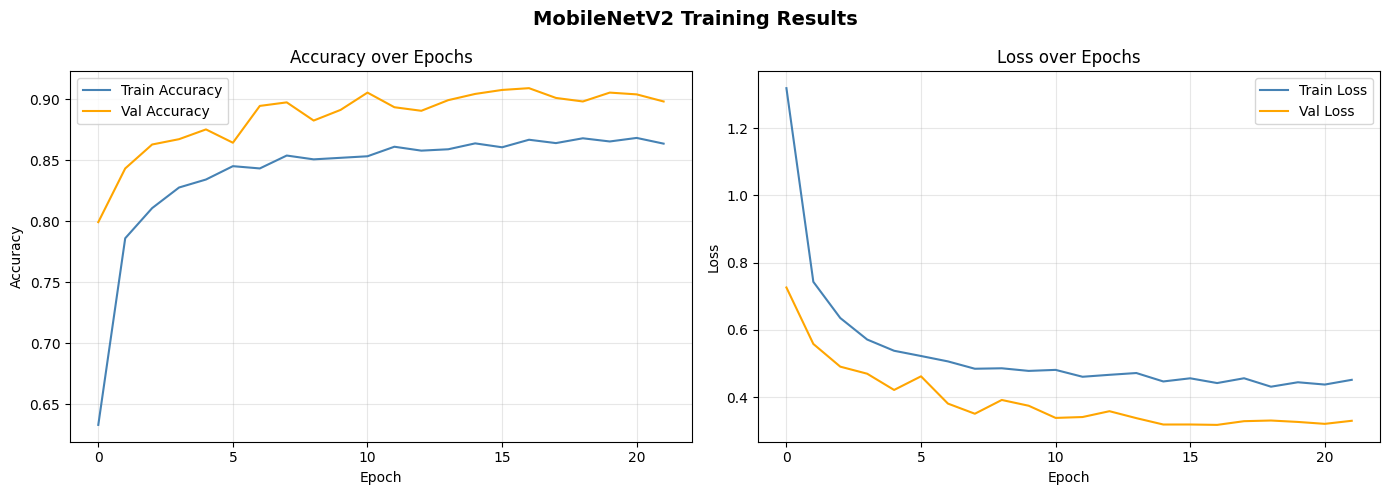

✅ Training results saved
   Epochs ran       : 22
   Best val accuracy: 90.91%
   Final train acc  : 86.37%


In [18]:
with open(HISTORY_SAVE_PATH) as f:
    hist = json.load(f)

epochs_range = list(range(len(hist["accuracy"])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 Training Results", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, hist["accuracy"],     label="Train Accuracy", color="steelblue")
axes[0].plot(epochs_range, hist["val_accuracy"], label="Val Accuracy",   color="orange")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, hist["loss"],     label="Train Loss", color="steelblue")
axes[1].plot(epochs_range, hist["val_loss"], label="Val Loss",   color="orange")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "mobilenet_training_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Training results saved")
print(f"   Epochs ran       : {len(epochs_range)}")
print(f"   Best val accuracy: {max(hist['val_accuracy'])*100:.2f}%")
print(f"   Final train acc  : {hist['accuracy'][-1]*100:.2f}%")

##  Evaluate on Test Set

In [19]:
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

accuracy  = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100
recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100
f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100

print("=" * 45)
print("  MobileNetV2 Fish Classification Results")
print("  Evaluated on: TEST SET")
print("=" * 45)
print(f"  Accuracy : {accuracy:.2f} %")
print(f"  Precision: {precision:.2f} %")
print(f"  Recall   : {recall:.2f} %")
print(f"  F1-Score : {f1:.2f} %")
print("=" * 45)

mobilenet_metrics = {
    "Accuracy" : round(accuracy, 2),
    "Precision": round(precision, 2),
    "Recall"   : round(recall, 2),
    "F1-Score" : round(f1, 2)
}
with open(os.path.join(DATA_DIR, "mobilenet_metrics.json"), "w") as f:
    json.dump(mobilenet_metrics, f)
print("✅ Metrics saved to mobilenet_metrics.json")

  MobileNetV2 Fish Classification Results
  Evaluated on: TEST SET
  Accuracy : 90.23 %
  Precision: 90.97 %
  Recall   : 90.23 %
  F1-Score : 90.26 %
✅ Metrics saved to mobilenet_metrics.json


##  Sample Predictions (3×3 Grid)

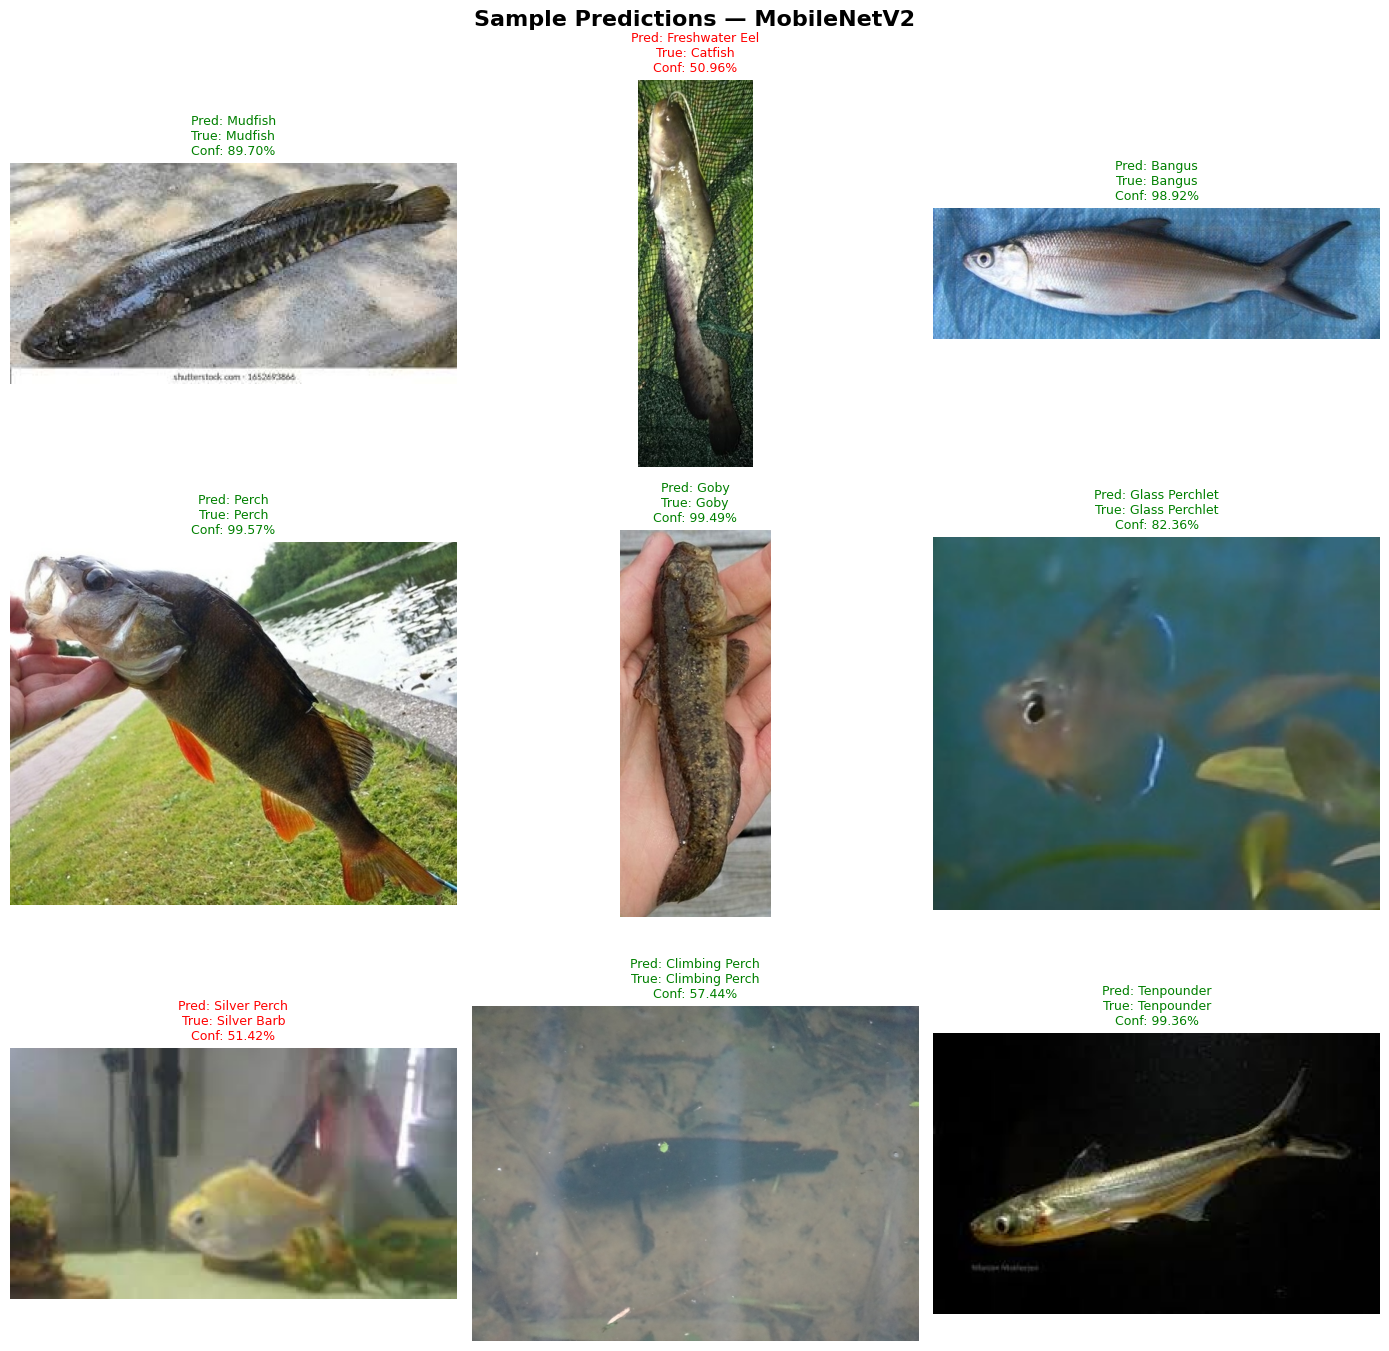

✅ Sample predictions saved


In [20]:
random.seed(42)
all_classes    = [c for c in sorted(os.listdir(TEST_DIR))
                  if os.path.isdir(os.path.join(TEST_DIR, c))]
sample_classes = random.sample(all_classes, min(9, len(all_classes)))

sample_images, sample_labels = [], []
for class_name in sample_classes:
    class_path = os.path.join(TEST_DIR, class_name)
    files = [f for f in os.listdir(class_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if files:
        sample_images.append(os.path.join(class_path, random.choice(files)))
        sample_labels.append(class_name)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Sample Predictions — MobileNetV2", fontsize=16, fontweight="bold")

for i, ax in enumerate(axes.flatten()):
    if i >= len(sample_images):
        ax.axis("off"); continue
    img_path   = sample_images[i]
    true_label = sample_labels[i]
    img        = Image.open(img_path).convert("RGB")
    resized    = img.resize(IMG_SIZE)
    arr        = np.expand_dims(np.array(resized), axis=0)
    preds      = model.predict(arr, verbose=0)[0]
    pred_idx   = np.argmax(preds)
    pred_label = class_names[pred_idx]
    confidence = float(preds[pred_idx]) * 100
    color      = "green" if pred_label == true_label else "red"
    ax.imshow(img); ax.axis("off")
    ax.set_title(
        f"Pred: {pred_label}\nTrue: {true_label}\nConf: {confidence:.2f}%",
        fontsize=9, color=color, pad=6
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "mobilenet_sample_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample predictions saved")

## 7️⃣ Interactive Demo — Upload & Predict

In [21]:
CONFIDENCE_THRESHOLD = 70

upload = widgets.FileUpload(accept="image/*", multiple=False)
output = widgets.Output()
display(upload, output)

def predict_image(change):
    with output:
        clear_output(wait=True)
        if not upload.value:
            return
        try:
            uploaded_file = (list(upload.value.values())[0]
                             if isinstance(upload.value, dict) else upload.value[0])
            image_bytes  = uploaded_file["content"]
            original_img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

            resized = original_img.resize(IMG_SIZE)
            arr     = np.expand_dims(np.array(resized), axis=0)
            preds   = model.predict(arr, verbose=0)[0]

            top3_idx    = preds.argsort()[-3:][::-1]
            predictions = [(class_names[i], float(preds[i]) * 100) for i in top3_idx]
            fish_name, confidence = predictions[0]

            img   = original_img.copy()
            scale = 900 / img.width
            img   = img.resize((900, int(img.height * scale)), Image.LANCZOS)
            draw  = ImageDraw.Draw(img)
            try:
                font = ImageFont.truetype("arial.ttf", 32)
            except:
                font = ImageFont.load_default()

            if confidence >= CONFIDENCE_THRESHOLD:
                text = f"Fish Type: {fish_name}\nConfidence: {confidence:.2f}%"
            else:
                lines = ["I'm not sure, but possibly:"]
                for name, conf in predictions:
                    lines.append(f"{name} — {conf:.1f}%")
                text = "\n".join(lines)

            bbox = draw.multiline_textbbox((0, 0), text, font=font, spacing=10)
            tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
            pad = 22
            x1, y1 = img.width - tw - 2*pad - 20, 20
            x2, y2 = img.width - 20, y1 + th + 2*pad
            draw.rectangle([x1, y1, x2, y2], fill="black")
            draw.multiline_text((x1+pad, y1+pad), text,
                                fill="white", font=font, spacing=10)

            if confidence >= CONFIDENCE_THRESHOLD:
                print(f"Fish Type : {fish_name}")
                print(f"Confidence: {confidence:.2f}%")
            else:
                print("I'm not sure, but possibly:")
                for name, conf in predictions:
                    print(f"  {name}: {conf:.2f}%")
            display(img)
        except Exception as e:
            print("Something went wrong:", e)

upload.observe(predict_image, names="value")

FileUpload(value=(), accept='image/*', description='Upload')

Output()